In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
from common.normalized_env_66k import CoppeliaSimEnv
# from common.normalized_env_66k_legloss import CoppeliaSimEnv
import os

# ======== Parameters (modify these as needed) ========= #
ENV_ID = "Medauroidea_66k_aug3c_uneven_flat"
ALGO = "airl_logit_vx"
FILENAME = "20251018-2026" 
STEP_NUM = "190000"  
EPISODE = 5 # 
start = 250 # 
end = 300 #2
fig_length = 4
fig_width = 2

STATES_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_states.csv"
ACTIONS_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_actions.csv"
VEL_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_velocities.csv"
FOOT_TRAJ_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_foot_trajs.csv"

os.makedirs(f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}/", exist_ok=True)
SAVE_PATH = f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}"

# ======== Read Data ======== #
states = pd.read_csv(STATES_PATH, header=None, index_col=None)
actions = pd.read_csv(ACTIONS_PATH, header=None, index_col=None)
actions.columns = ['LF_ThC', 'LF_CTr', 'LF_FTi', 'LM_ThC', 'LM_CTr', 'LM_FTi', 'LH_ThC', 'LH_CTr', 'LH_FTi',
                                     'RF_ThC', 'RF_CTr', 'RF_FTi', 'RM_ThC', 'RM_CTr', 'RM_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi']
                                    #  'RF_ThC', 'RF_CTr', 'RF_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi']
velocities = pd.read_csv(VEL_PATH, header=None, index_col=None)
foot_trajs = pd.read_csv(FOOT_TRAJ_PATH, header=None, index_col=None)

# ======== Denormalize Data ======== #
env = CoppeliaSimEnv(simulation = False)
states = pd.DataFrame(env.denormalize_observation(states))
actions = env.denormalize_action(actions)

states.columns = [
                #   'body_x', 'body_y',
                  'body_z', 'body_roll', 'body_pitch', 'body_yaw', 
                  'LF_ThC', 'LF_CTr', 'LF_FTi', 'LM_ThC', 'LM_CTr', 'LM_FTi', 'LH_ThC', 'LH_CTr', 'LH_FTi',
                  'RF_ThC', 'RF_CTr', 'RF_FTi', 'RM_ThC', 'RM_CTr', 'RM_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi',
                  'force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH',
                #   'foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH',
                #   'contact_FL', 'contact_ML', 'contact_HL', 'contact_FR', 'contact_MR', 'contact_HR'
                  ]

forces = states[['force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH']].copy()


# ======== Gait Analysis ======== #
LEG_ORDER = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']

def _find_touchdowns(binary_array: np.ndarray):
    """返回 0->1 的接触跃迁索引 touchdown """
    b = np.asarray(binary_array).astype(int)
    td = (b[1:] == 1) & (b[:-1] == 0)
    return np.where(td)[0] + 1

def _cycles_and_duty(contact_1d: np.ndarray):
    """基于相邻 touchdown 划分步周期，并计算该周期内 duty factor。"""
    td_idx = _find_touchdowns(contact_1d)
    cycles, duty = [], []
    if len(td_idx) < 2:
        return cycles, duty
    for i in range(len(td_idx) - 1):
        a, b = td_idx[i], td_idx[i + 1]
        if b - a <= 1:
            continue
        cyc_mask = contact_1d[a:b]
        cycles.append((a, b))
        duty.append(float(cyc_mask.mean()))
    return cycles, duty

def _leg_phase_series(contact_1d: np.ndarray):
    """在每个 touchdown->touchdown 周期内，线性相位 0~1 (端点不含 1), 其他位置为 NaN。"""
    n = len(contact_1d)
    td = _find_touchdowns(contact_1d)
    phase = np.full(n, np.nan, dtype=float)
    if len(td) < 2:
        return phase
    for i in range(len(td) - 1):
        a, b = td[i], td[i + 1]
        L = b - a
        if L > 0:
            phase[a:b] = np.linspace(0.0, 1.0, L, endpoint=False)
    return phase

def _circ_mean_phase_diff(phase_a, phase_b):
    """返回相位差(0~1 周期)的圆平均值与同步指数 R(0~1)。"""
    mask = ~np.isnan(phase_a) & ~np.isnan(phase_b)
    if mask.sum() == 0:
        return np.nan, np.nan
    d = (phase_b[mask] - phase_a[mask]) % 1.0
    ang = 2 * np.pi * d
    C, S = np.cos(ang).mean(), np.sin(ang).mean()
    mean_ang = np.arctan2(S, C)
    mean_phase = (mean_ang / (2 * np.pi)) % 1.0
    R = float(np.sqrt(C**2 + S**2))
    return float(mean_phase), R

def gait_quant_from_foot_z(foot_trajs_df, forces, start, end, use_foot_trajs=True, save_prefix="z"):
    """
    使用“足端 z < z_threshold”为接地规则,计算并输出:
      - 步态栅格图 (填充=stance)
      - 各腿 Duty Factor 条形图（按周期平均）
      - 相位差热图 (0~1 周期)
      - 同步指数热图 (R∈[0,1])
      - Tripod Index (两套 tripod 同时支撑占比)
      - duty_factor_summary.csv / phase_diff_matrix.csv / sync_index_matrix.csv / tripod_index.txt
    """
    # 1) 取区间并二值化接地
    # foot_trajs 无 header，列顺序：LF_z, LM_z, LH_z, RF_z, RM_z, RH_z
    if use_foot_trajs:
        threshold = 0.02
        ft = foot_trajs_df.iloc[:, :6].to_numpy()  # (T, 6)
        ft = ft[start:end]                          # (T', 6)
        contacts = (ft < threshold).astype(int)   # (T', 6); 1=stance
    else:
        threshold = 0.27
        fc = forces.to_numpy()                      # (T, 6)
        fc = fc[start:end]                          # (T', 6)
        contacts = (fc > threshold).astype(int)    # (T', 6); 1=stance

    #    2.2 可选：块状栅格（更接近传统 raster）
    plt.figure(figsize=(fig_length, fig_width))
    T = contacts.shape[0]
    for i in range(6):
        in_seg = False
        seg_start = 0
        for t in range(T):
            if contacts[t, i] == 1 and not in_seg:
                in_seg = True; seg_start = t
            if (contacts[t, i] == 0 or t == T - 1) and in_seg:
                seg_end = t if contacts[t, i] == 0 else t + 1
                plt.fill_between([seg_start, seg_end], i, i + 1, step="post")
                in_seg = False
    plt.yticks(np.arange(0.5, 6.5, 1), LEG_ORDER)
    plt.xlabel("Time (frames)")
    plt.title(f"Gait Raster")
    plt.tight_layout()
    plt.show()

    # 3) 按周期的 Duty Factor
    duty_means, duty_stds, n_cycles = [], [], []
    for i in range(6):
        _, dfs = _cycles_and_duty(contacts[:, i])
        dfs = np.array(dfs) if len(dfs) else np.array([])
        duty_means.append(dfs.mean() if dfs.size else np.nan)
        duty_stds.append(dfs.std(ddof=1) if dfs.size > 1 else np.nan)
        n_cycles.append(int(dfs.size))
    df_summary = pd.DataFrame({
        "leg": LEG_ORDER,
        "duty_mean": duty_means,
        "duty_std": duty_stds,
        "n_cycles": n_cycles,
    })

    plt.figure(figsize=(fig_length, fig_width))
    plt.bar(df_summary["leg"], df_summary["duty_mean"])
    plt.ylabel("Duty Factor (mean)")
    plt.title(f"Duty Factor per Leg")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # 4) 相位差矩阵 & 同步指数矩阵
    phases = [ _leg_phase_series(contacts[:, i]) for i in range(6) ]
    phase_diff_mat = np.full((6, 6), np.nan, dtype=float)
    sync_mat = np.full((6, 6), np.nan, dtype=float)
    for i in range(6):
        for j in range(6):
            m, r = _circ_mean_phase_diff(phases[i], phases[j])
            phase_diff_mat[i, j] = m
            sync_mat[i, j] = r

    phase_diff_mat_df = pd.DataFrame(phase_diff_mat, index=LEG_ORDER, columns=LEG_ORDER)
    sync_mat_df = pd.DataFrame(sync_mat, index=LEG_ORDER, columns=LEG_ORDER)

    plt.figure(figsize=(4, 3))
    plt.imshow(phase_diff_mat, aspect="equal")
    plt.colorbar()
    plt.xticks(range(6), LEG_ORDER)
    plt.yticks(range(6), LEG_ORDER)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.title("Phase Difference Matrix", fontsize = 18)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.imshow(sync_mat, aspect="equal", vmin=0, vmax=1)
    plt.colorbar()
    plt.xticks(range(6), LEG_ORDER)
    plt.yticks(range(6), LEG_ORDER)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.title("Synchronization Matrix", fontsize = 18)
    plt.tight_layout()
    plt.show()

    # 5) Tripod Index
    # 两套 tripod：{LF, RM, RH} 与 {RF, LM, LH}
    idx = {leg: k for k, leg in enumerate(LEG_ORDER)}
    tripod_A = contacts[:, idx["LF"]] & contacts[:, idx["RM"]] & contacts[:, idx["RH"]]
    tripod_B = contacts[:, idx["RF"]] & contacts[:, idx["LM"]] & contacts[:, idx["LH"]]
    tripod_index = float((tripod_A | tripod_B).mean())

    print(f"[gait_quant_from_foot_z] Tripod index ({save_prefix}) =", tripod_index)
    return tripod_index, df_summary, phase_diff_mat_df, sync_mat_df


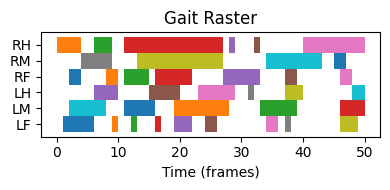

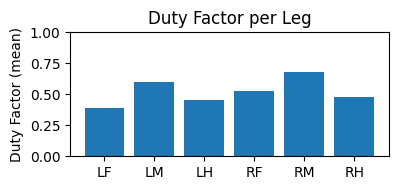

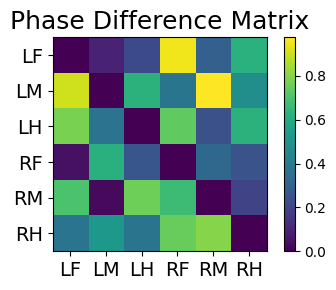

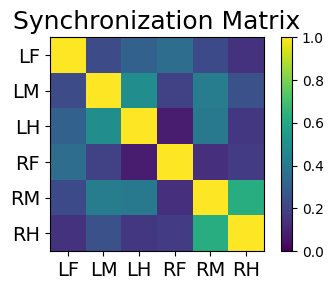

[gait_quant_from_foot_z] Tripod index (footz) = 0.2


In [39]:
tripod_index, df_summary, phase_diff_mat_df, sync_mat_df= gait_quant_from_foot_z(foot_trajs, forces, start, end, use_foot_trajs=False, save_prefix="footz")

In [40]:
df_summary

,leg,duty_mean,duty_std,n_cycles
0,LF,0.389931,0.212391,8
1,LM,0.599016,0.093227,4
2,LH,0.451768,0.241010,5
3,RF,0.527946,0.214521,6
4,RM,0.680135,0.131830,3
5,RH,0.479044,0.367879,4


In [41]:
phase_diff_mat_df

,LF,LM,LH,RF,RM,RH
LF,0.000000,0.093561,0.218387,0.956955,0.299250,0.624745
LM,0.906439,0.000000,0.627324,0.379757,0.976093,0.480469
LH,0.781613,0.372676,0.000000,0.737656,0.240356,0.626092
RF,0.043045,0.620243,0.262344,0.000000,0.330116,0.249997
RM,0.700750,0.023907,0.759644,0.669884,0.000000,0.200479
RH,0.375255,0.519531,0.373908,0.750003,0.799521,0.000000


In [42]:
sync_mat_df

,LF,LM,LH,RF,RM,RH
LF,1.000000,0.229466,0.311792,0.356609,0.223778,0.146803
LM,0.229466,1.000000,0.490732,0.192614,0.419696,0.248361
LH,0.311792,0.490732,1.000000,0.075535,0.403676,0.161217
RF,0.356609,0.192614,0.075535,1.000000,0.135410,0.178173
RM,0.223778,0.419696,0.403676,0.135410,1.000000,0.622297
RH,0.146803,0.248361,0.161217,0.178173,0.622297,1.000000
